In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder
from statsmodels.genmod.families.varfuncs import binary


# Extract - Load - Transform (ETL)

In [6]:
data_directory = Path(__name__).resolve().parent.parent / 'data'
df = pd.read_csv(str(data_directory) + '/Telco_Customer_Churn.csv')
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['TotalCharges'] = df['TotalCharges'].map(lambda x: float(x) if x != ' ' else 0)
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [12]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [13]:
# Выделение/Разбивка столбцов по содержимому типу данных
num_columns = ['TotalCharges', 'MonthlyCharges', 'tenure']
cols_passthrough = ['SeniorCitizen']
bool_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multiclass_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
print(len(num_columns + bool_columns + multiclass_columns + cols_passthrough))

19


In [14]:
for col in bool_columns:
    print(df[col].unique())

['Female' 'Male']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['Yes' 'No']


In [15]:
for col in multiclass_columns:
    print(df[col].unique())

['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [16]:
# Преобразование данных
data_transform = ColumnTransformer([
        ('num_cols', StandardScaler(), num_columns),
        ('pass', 'passthrough', cols_passthrough),
        ('le', OrdinalEncoder(), bool_columns),
        ('ohe', OneHotEncoder(handle_unknown='ignore'), multiclass_columns)
    ], n_jobs=-1)

X = df.drop(columns=['Churn'], axis=1)
le = LabelEncoder()
y = le.fit_transform(df['Churn'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train = data_transform.fit_transform(X_train)
X_test = data_transform.transform(X_test)

feature_names = data_transform.get_feature_names_out()
feature_names = [col.split('__')[1] for col in feature_names]

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)


# Exploratory Data Analysis

In [17]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

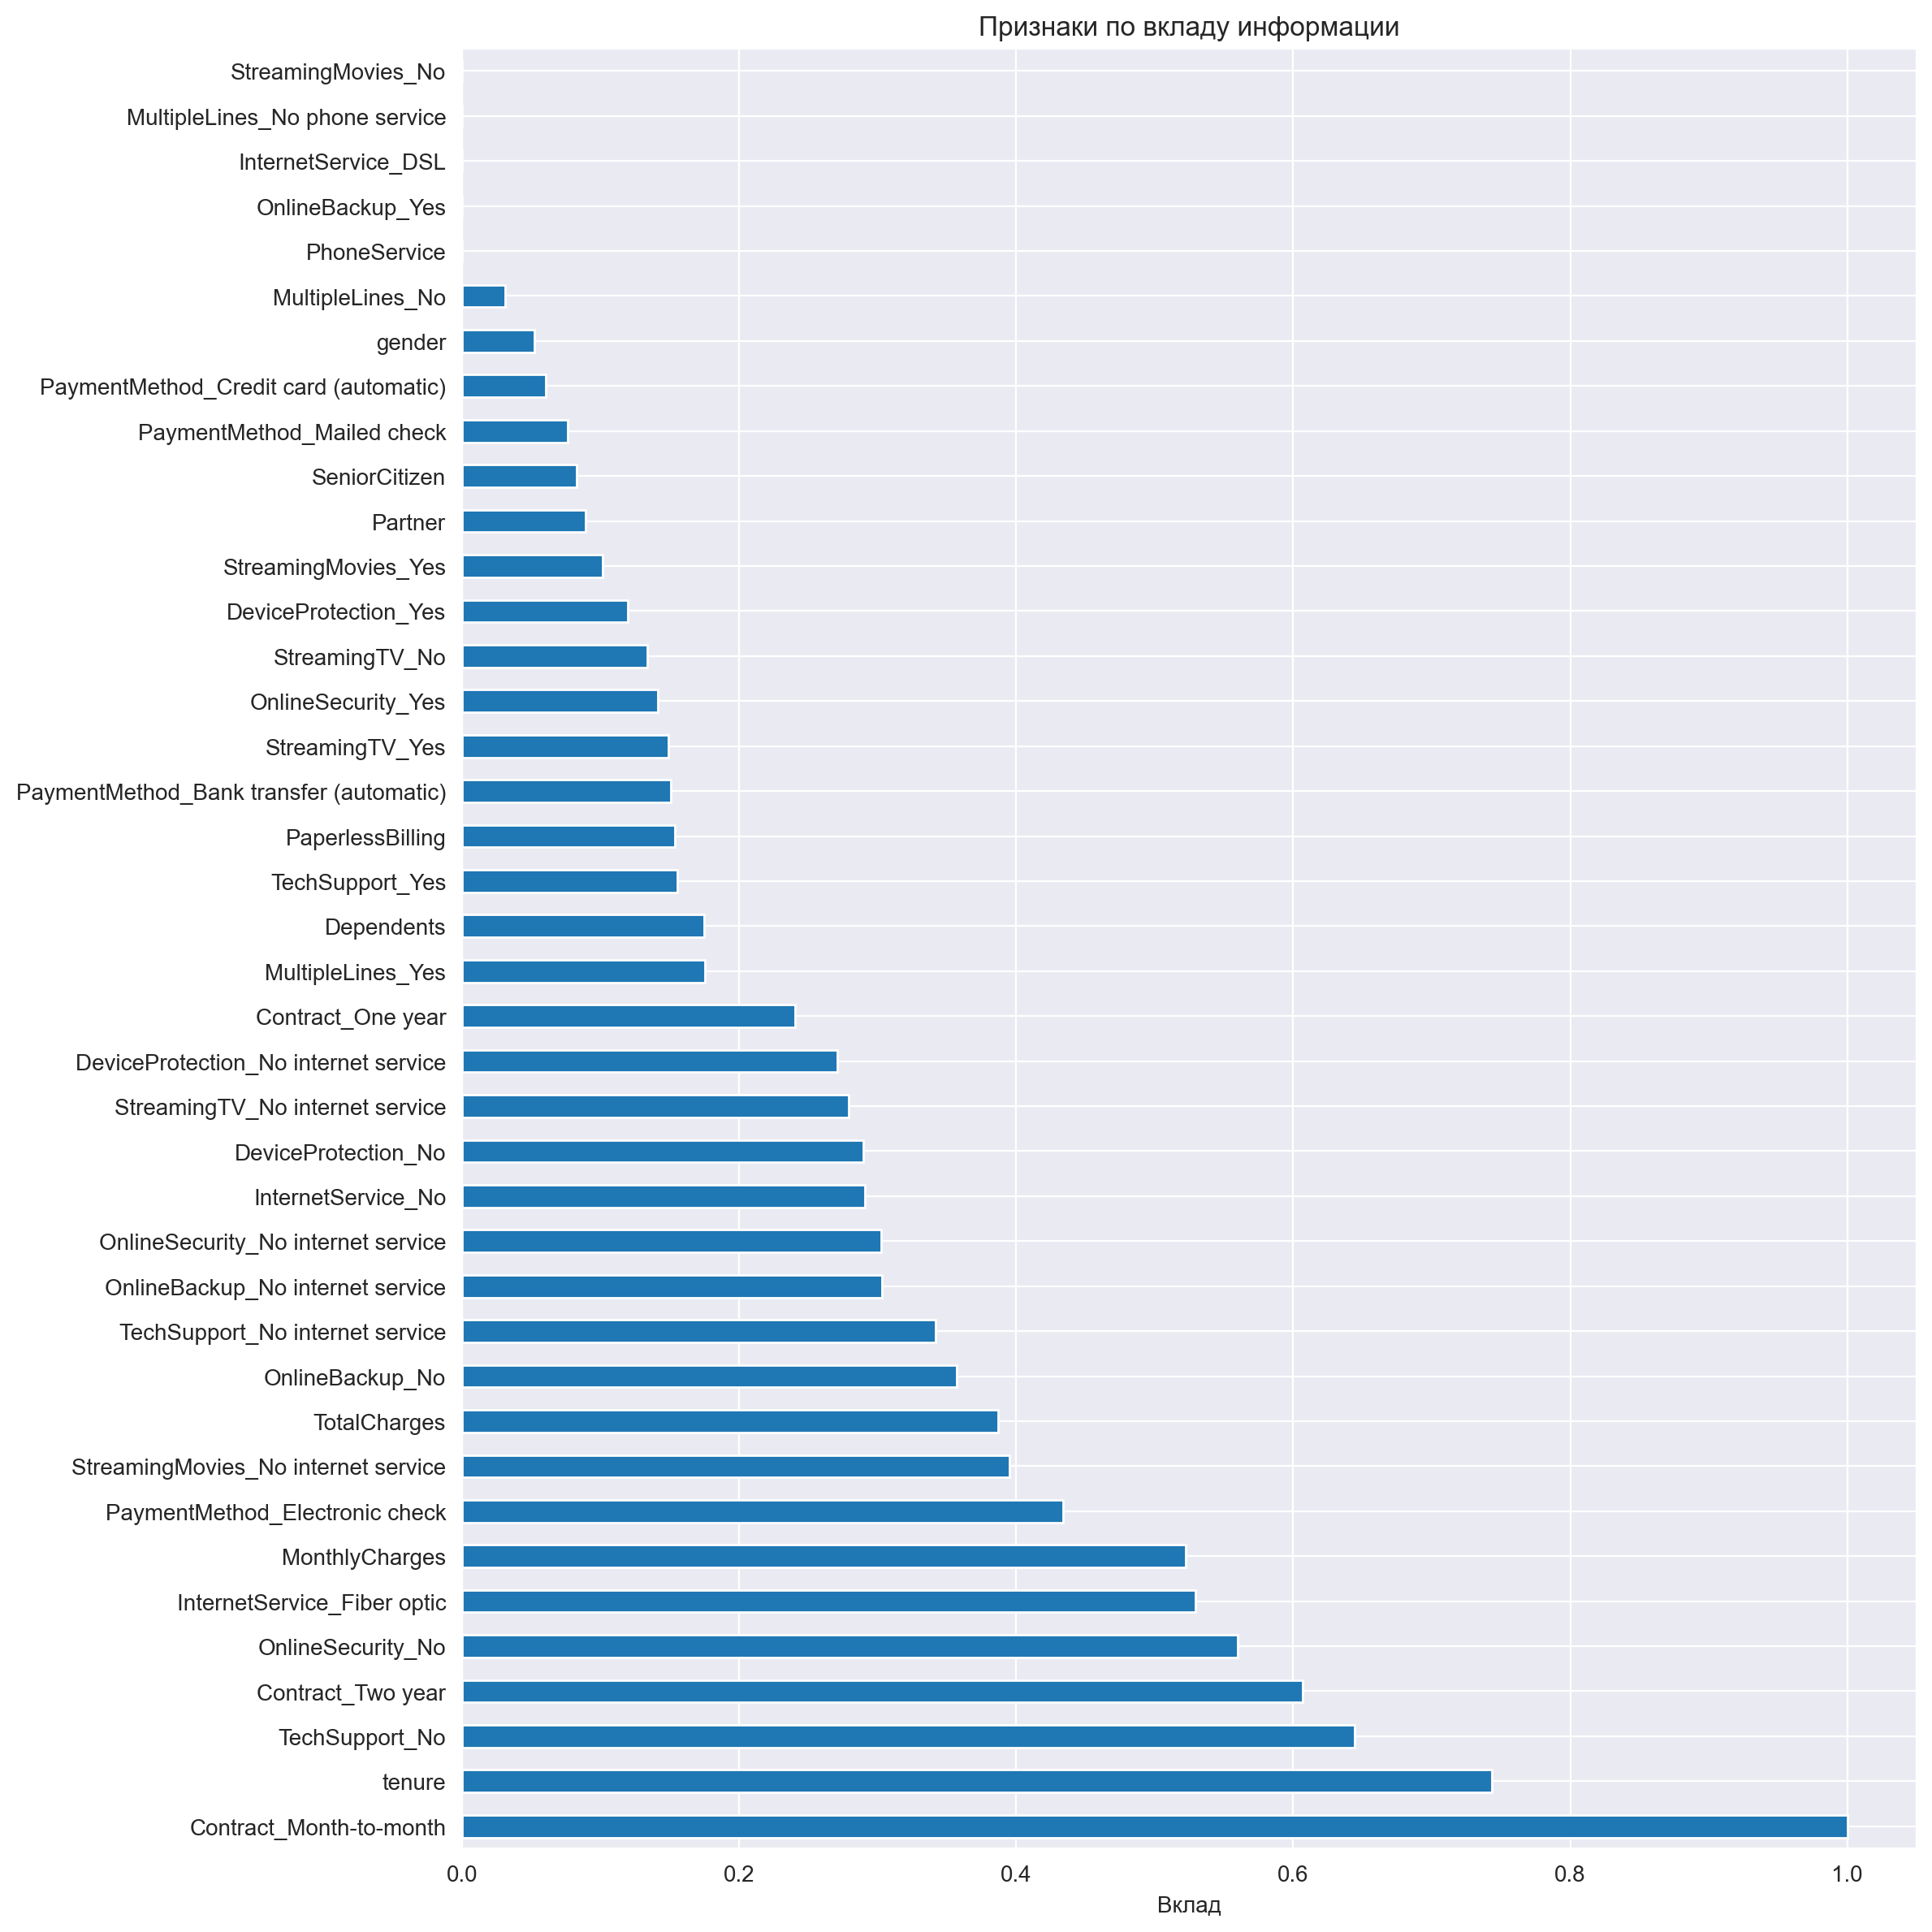

In [18]:
# Оценка каждого из признаков по вкладу информации в целевую переменную
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi = mi / mi.max()
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize = (12, 12), dpi=200)
mi_series.plot(kind='barh')
plt.title('Признаки по вкладу информации')
plt.xlabel('Вклад')
plt.tight_layout()

In [19]:
# Удаление неинформативных признаков
columns_to_drop = mi_series[mi_series == 0].index.tolist()
X_train = X_train.drop(columns=columns_to_drop, axis=1)
X_test = X_test.drop(columns=columns_to_drop, axis=1)
columns_to_drop

['PhoneService',
 'OnlineBackup_Yes',
 'InternetService_DSL',
 'MultipleLines_No phone service',
 'StreamingMovies_No']

In [20]:
train_data = X_train.copy()
train_data['Churn'] = y_train

test_data = X_test.copy()
test_data['Churn'] = y_test

train_data.to_csv(data_directory / f'train_data.csv', index=False)
test_data.to_csv(data_directory / f'test_data.csv', index=False)

In [21]:
X_train.shape[0] + X_test.shape[0]

7043

Text(0.5, 0, 'Время пользования клиентом \nуслугами компании, число \nмесяцев')

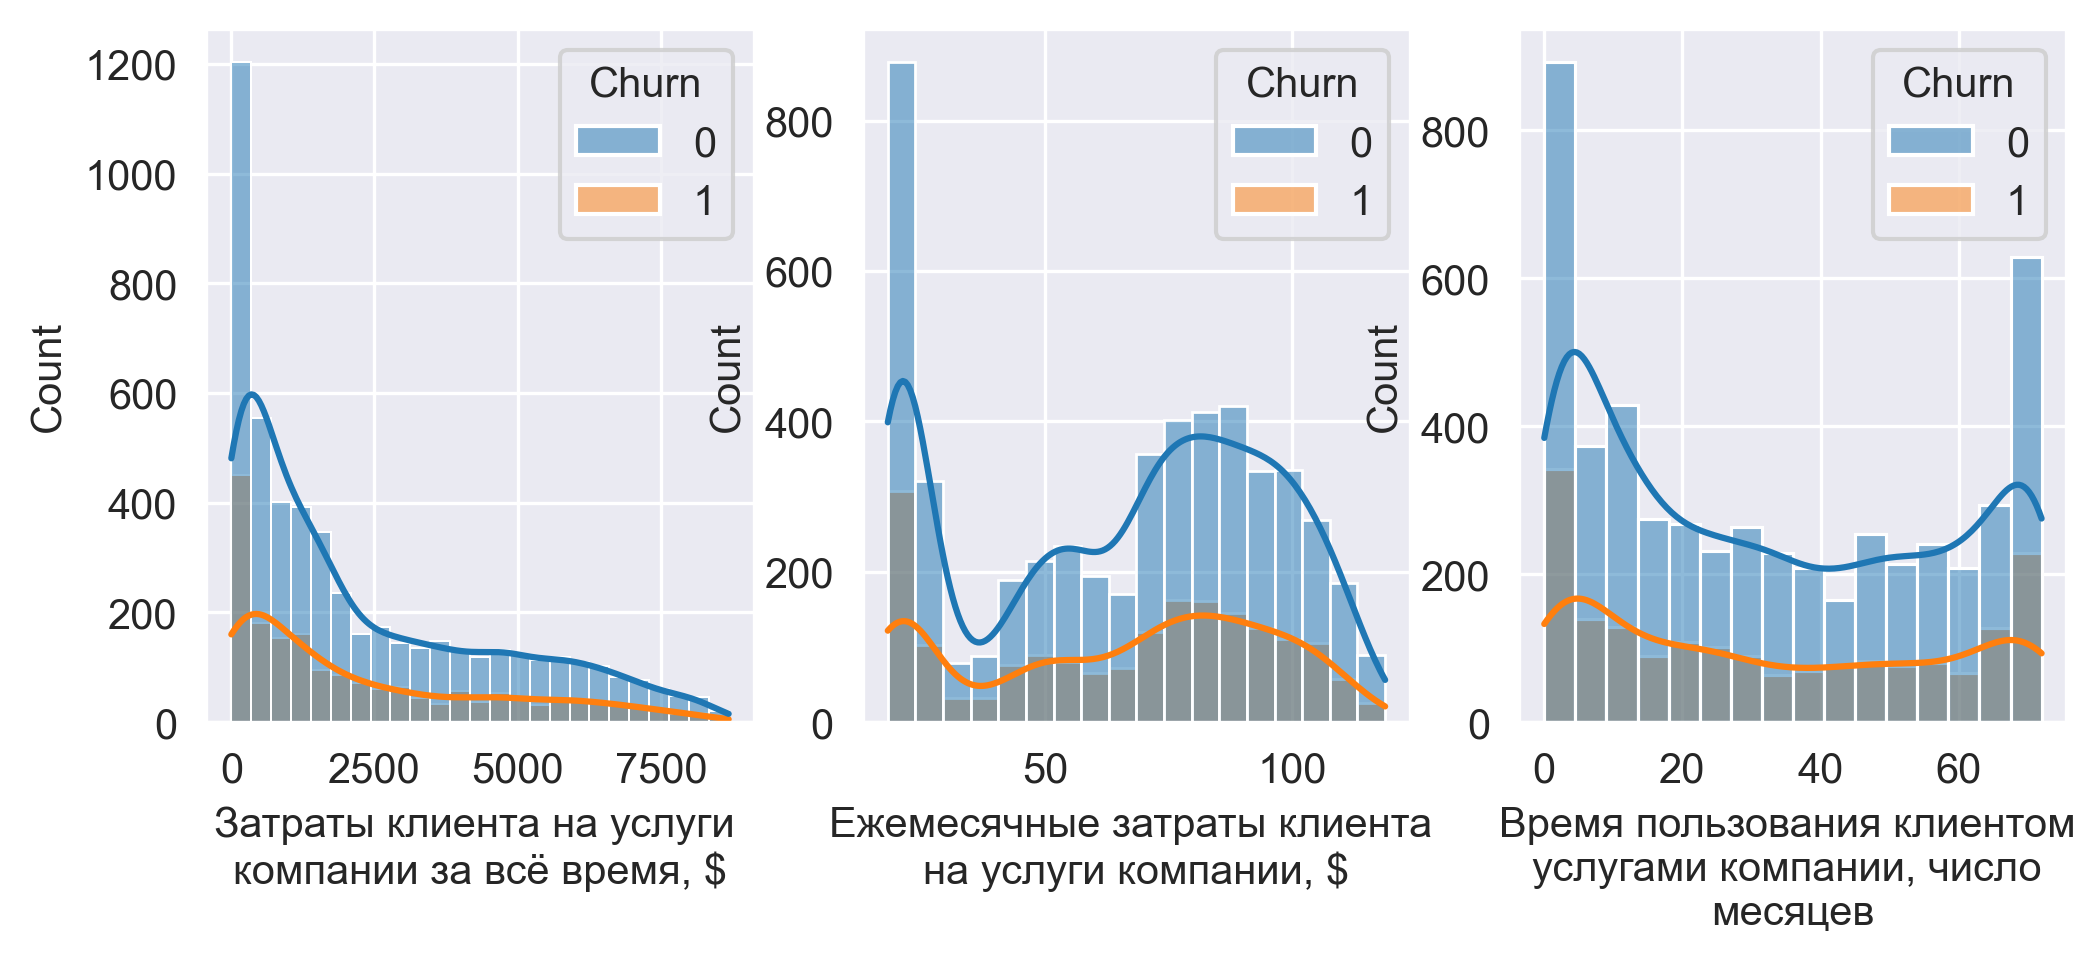

In [22]:
data_analysis = pd.concat([pd.read_csv(data_directory / 'train_data.csv'), pd.read_csv(data_directory / 'test_data.csv')], axis=0)
data_analysis[num_columns] = df[num_columns]
binary_columns = data_analysis.drop(columns=num_columns).columns

fig, ax = plt.subplots(1, len(num_columns), figsize=(8, 3), dpi=300)
for i, col in enumerate(num_columns):
    sns.histplot(data=data_analysis, x=num_columns[i], hue='Churn', kde=True, ax=ax[i])
ax[0].set_xlabel('Затраты клиента на услуги \nкомпании за всё время, $')
ax[1].set_xlabel('Ежемесячные затраты клиента \nна услуги компании, $')
ax[2].set_xlabel('Время пользования клиентом \nуслугами компании, число \nмесяцев')


Text(0.5, 0, 'Время пользования клиентом \nуслугами компании, число \nмесяцев')

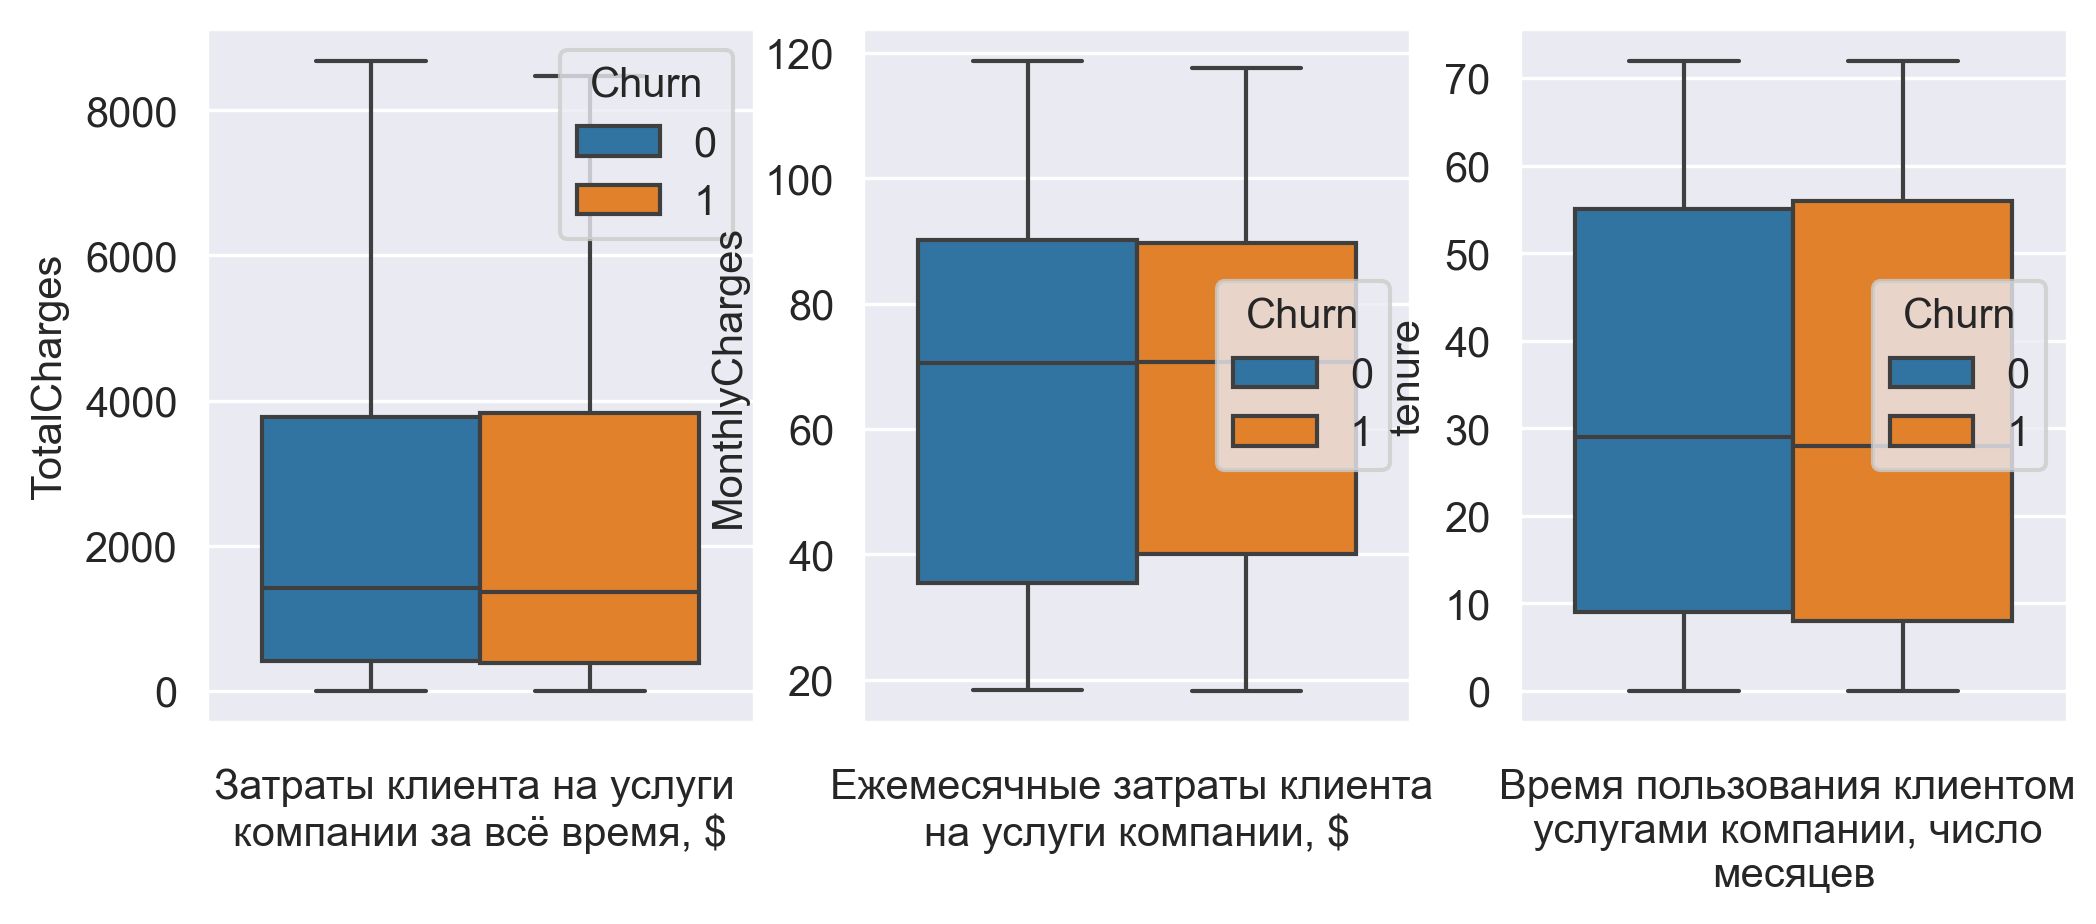

In [23]:
# выбросы корр
fig, ax = plt.subplots(1, len(num_columns), figsize=(8, 3), dpi=300)
for i, col in enumerate(num_columns):
    sns.boxplot(data=data_analysis, y=num_columns[i], hue='Churn', ax=ax[i])
ax[0].set_xlabel('Затраты клиента на услуги \nкомпании за всё время, $')
ax[1].set_xlabel('Ежемесячные затраты клиента \nна услуги компании, $')
ax[2].set_xlabel('Время пользования клиентом \nуслугами компании, число \nмесяцев')

Text(0.5, 0, 'Время пользования клиентом \nуслугами компании, число \nмесяцев')

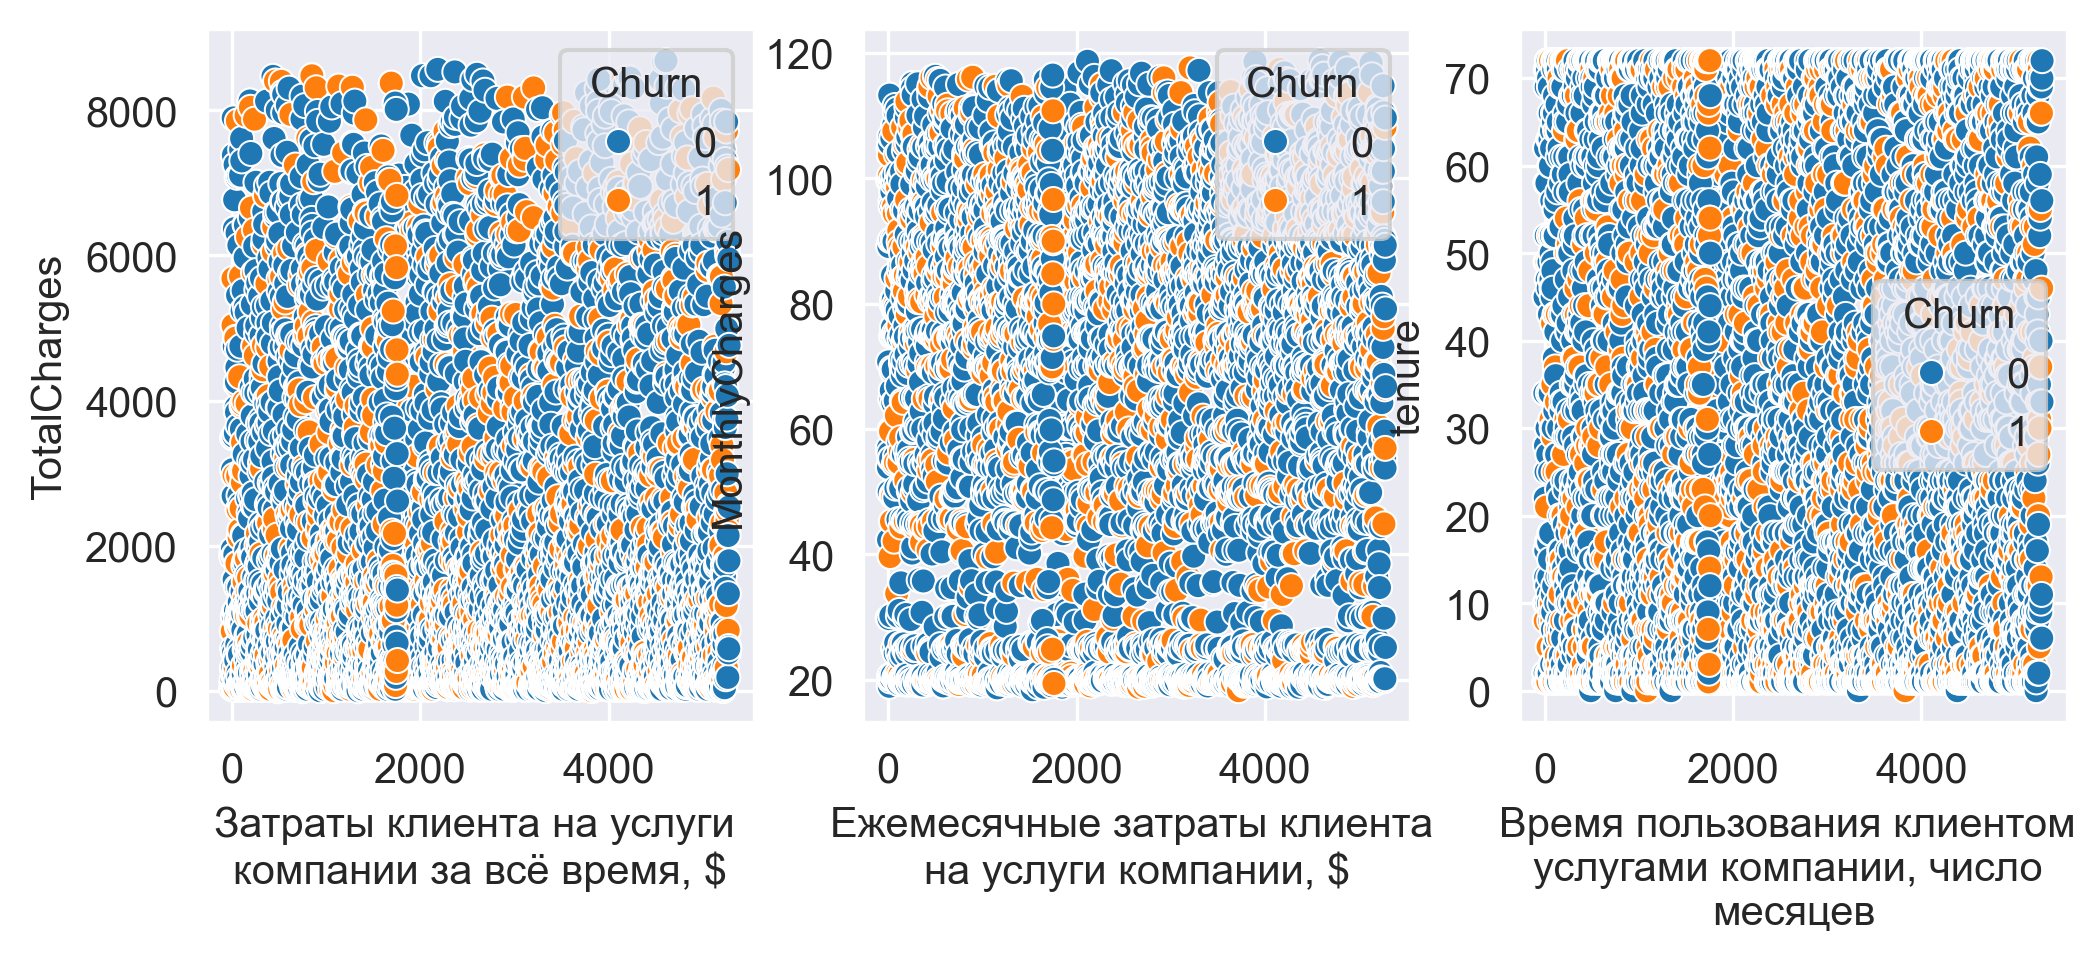

In [24]:
fig, ax = plt.subplots(1, len(num_columns), figsize=(8, 3), dpi=300)
for i, col in enumerate(num_columns):
    sns.scatterplot(data=data_analysis, x=data_analysis.index, y=num_columns[i], hue='Churn', ax=ax[i])
ax[0].set_xlabel('Затраты клиента на услуги \nкомпании за всё время, $')
ax[1].set_xlabel('Ежемесячные затраты клиента \nна услуги компании, $')
ax[2].set_xlabel('Время пользования клиентом \nуслугами компании, число \nмесяцев')

<Axes: >

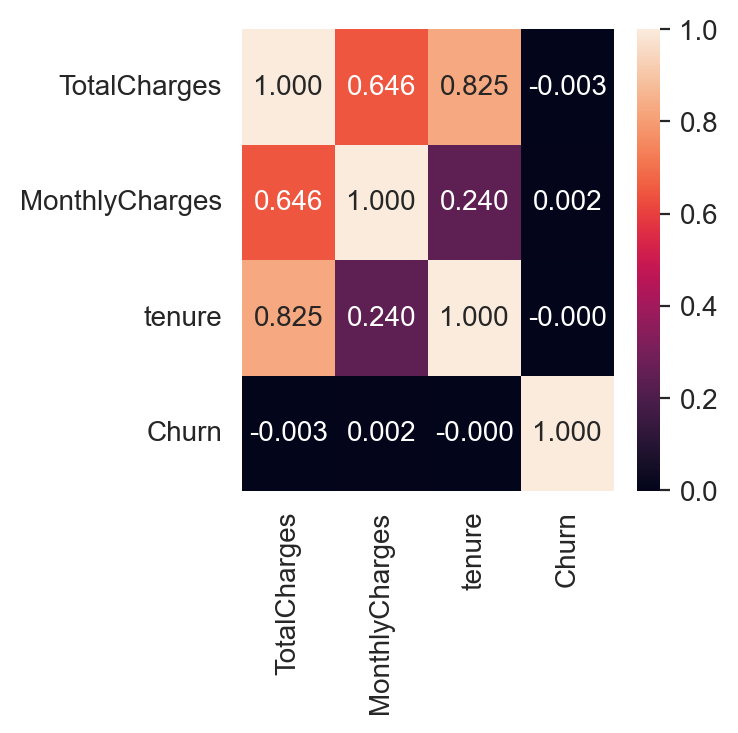

In [25]:
cols = num_columns + ['Churn']
corr = data_analysis[cols].corr()

plt.figure(figsize = (3, 3), dpi=200)
sns.heatmap(corr, annot=True, fmt='.3f')